CAPAR, Fehime 605437

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import class_weight

In [ ]:
!pip install tensorflow

In [ ]:
!pip install -U tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_PATH = '/content/biodeg_cleaned.xlsx'
TEST_SIZE = 0.20
N_SPLITS = 5

# upload data
df = pd.read_excel(DATA_PATH, engine='openpyxl')

# target and features
assert 'Class' in df.columns, "No Class Column"
y = df['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
X = df.drop(columns=['Class'])

In [ ]:
y

,Class
0,0
1,0
2,0
3,0
4,0
...,...
1050,1
1051,1
1052,1
1053,1


In [ ]:
X

,SpMax_L,nHM,F01[N-N],nCb,C%,nO,F03[C-N],F03[C-O],Me,Mi,nArNO2,nCIR,B01[C-Br],B03[C-Cl],SpMax_A,nHDon,nN,nArCOOR,nX
0,3.919,0,0,0,31.4,0,0,0,0.960,1.142,0,0,0,0,1.932,0,0,0,0
1,4.170,0,0,0,30.8,1,0,1,0.989,1.144,0,1,0,0,2.214,0,0,0,0
2,3.932,0,0,0,26.7,4,0,0,1.009,1.152,0,0,0,0,1.942,1,0,0,0
3,3.000,0,0,0,20.0,2,0,0,1.108,1.167,0,0,0,0,1.414,1,0,0,0
4,4.236,0,0,0,29.4,4,0,2,1.004,1.147,0,0,0,0,1.985,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050,5.431,0,0,0,32.1,1,1,2,0.982,1.144,0,1,0,0,2.394,1,1,0,0
1051,5.287,0,0,0,35.3,9,9,21,1.043,1.140,0,1,0,0,2.462,0,3,0,0
1052,4.869,0,1,5,44.4,4,14,9,1.016,1.123,1,3,0,0,2.314,0,5,1,0
1053,5.158,2,0,9,56.1,0,44,0,1.007,1.093,0,147,0,1,2.622,0,8,0,1


In [ ]:
# Feature engineering
count_cols = ['nHM', 'nO', 'nN', 'nArNO2', 'nCIR']
for c in count_cols:
    if c in X.columns:
        X[f'log_{c}'] = np.log1p(X[c])  # ln(x+1)

# rates
if 'nN' in X.columns and 'nO' in X.columns:
    X['N_to_O_Ratio'] = X['nN'] / (X['nO'] + 1)

In [ ]:
# intensity of halojen
br_col = None
cl_col = None
for col in X.columns:
    if 'C-Br' in col and 'B01' in col: br_col = col
    if 'C-Cl' in col and 'B03' in col: cl_col = col
if br_col and cl_col and ('nHM' in X.columns):
    X['Halo_Density'] = (X[br_col] + X[cl_col]) / (X['nHM'] + 1)

# Spektral indeks interaction
if 'SpMax_L' in X.columns and {'nN','nO','nArNO2'}.issubset(X.columns):
    X['Index_Interaction'] = X['SpMax_L'] * (X['nN'] + X['nO'] + X['nArNO2'])

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# 7) NN structure
def build_model(input_dim, config):
    """model = keras.Sequential(name=config.get('name', 'NN'))
    # Hidden layers
    for i, (units, dropout) in enumerate(zip(config['units'], config['dropout'])):
        if i == 0:
            model.add(layers.Dense(units, activation=config.get('activation','relu'),
                                   input_dim=input_dim))
        else:
            model.add(layers.Dense(units, activation=config.get('activation','relu')))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))
    # output layer
    model.add(layers.Dense(1, activation='sigmoid'))
    # Optimizasyon
    opt = keras.optimizers.Adam(learning_rate=config.get('lr', 1e-3))
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model"""

    model = keras.Sequential(name=cfg.get('name', 'NN'))
    #Keras 3 recommendation: separate input layer
    model.add(keras.Input(shape=(input_dim,), name="model_input"))
    for units, dropout in zip(cfg['units'], cfg['dropout']):
        model.add(layers.Dense(units, activation=cfg.get('activation', 'relu')))
        if dropout and dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    opt = keras.optimizers.Adam(learning_rate=cfg.get('lr', 1e-3))
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
# NN achitectures which will be tried
candidates = [
    {'name':'NN_32x2_dp0.2',       'units':[32, 32],     'dropout':[0.2, 0.2],     'lr':1e-3},
    {'name':'NN_64-32-16_dp0.3',   'units':[64, 32, 16], 'dropout':[0.3, 0.3, 0.3],'lr':1e-3},
    {'name':'NN_128-64_dp0.5',     'units':[128, 64],    'dropout':[0.5, 0.5],     'lr':5e-4},
    {'name':'NN_64x3_dp0.2',       'units':[64, 64, 64], 'dropout':[0.2, 0.2, 0.2],'lr':1e-3},
]

# 5-fold stratified CV function
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


In [ ]:
def cross_val_score_nn(X_scaled, y, config):
    accs = []
    cw = class_weight.compute_class_weight(class_weight='balanced',
                                           classes=np.array([0,1]),
                                           y=y)
    cw_dict = {0: cw[0], 1: cw[1]}
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_scaled, y), start=1):
        X_tr, X_val = X_scaled[tr_idx], X_scaled[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = build_model(X_scaled.shape[1], config)
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                           restore_best_weights=True)
        # trsin
        history = model.fit(
            X_tr, y_tr,
            epochs=200, batch_size=32,
            validation_data=(X_val, y_val),
            callbacks=[es],
            verbose=0,
            class_weight=cw_dict
        )
        # Evaluate
        y_val_pred = (model.predict(X_val, verbose=0).ravel() >= 0.5).astype(int)
        acc = accuracy_score(y_val, y_val_pred)
        accs.append(acc)

        # clear the resources
        tf.keras.backend.clear_session()
    return float(np.mean(accs)), float(np.std(accs))

In [ ]:
# 10) evaluate the sarchitectures, and choose the best 3
results = []
for cfg in candidates:
    mean_acc, std_acc = cross_val_score_nn(X_train_scaled, y_train, cfg)
    results.append({'Model':cfg['name'], 'CV_mean_acc':mean_acc, 'CV_std_acc':std_acc})

res_df = pd.DataFrame(results).sort_values('CV_mean_acc', ascending=False)
print("\n=== 5-Fold CV Results (Train/Val) ===")
print(res_df)


=== 5-Fold CV Results (Train/Val) ===
               Model  CV_mean_acc  CV_std_acc
3      NN_64x3_dp0.2     0.878015    0.026990
0      NN_32x2_dp0.2     0.870900    0.029180
1  NN_64-32-16_dp0.3     0.867357    0.030149
2    NN_128-64_dp0.5     0.857868    0.029774


"""
##Cross‑validated NN Performance (5‑fold)

Among the four tested architectures, **NN_64x3_dp0.2** achieves the highest mean validation accuracy (**87.8%**) with a moderate variance across folds (~2.7% std). This suggests that a **three‑layer network with moderate dropout (0.2)** provides a good balance between capacity and regularization for this dataset.  

The two smaller models (**NN_32x2_dp0.2** and **NN_64‑32‑16_dp0.3**) follow closely, indicating that **reasonable depth plus regularization** can reach robust accuracy without overfitting.  

The largest network with heavier dropout (**NN_128‑64_dp0.5**) does not outperform the top configuration—likely because **excessive dropout dampens learning**, while the higher capacity is not fully beneficial given the data size.  

Confidence intervals (mean ± 1.96·std/√5) for the top models **overlap**, so absolute differences should be interpreted cautiously; however, the ranking is consistent.  

**Next steps:**  
- Validate on the held‑out test set (accuracy, confusion matrix, F1/ROC‑AUC/PR‑AUC).  
- Optionally calibrate the decision threshold (beyond 0.5) to better balance precision/recall in case of class imbalance.  

**Implementation details:**  
ResultsResults are driven by:  
- **StratifiedKFold (5‑fold)** to preserve class ratios  
- **EarlyStopping** to prevent overfitting  
- `class_weight='balanced'` for fairness under imbalance  
- **StandardScaler** for stable optimization dynamics  


In [ ]:
# Evaluate the best 3 structures on test-set
best3 = res_df.head(3)['Model'].tolist()

def get_cfg_by_name(name):
    return next(c for c in candidates if c['name'] == name)


>>> NN_32x2_dp0.2 – Test Accuracy: 0.8531
              precision    recall  f1-score   support

         NRB       0.79      0.77      0.78        71
          RB       0.89      0.89      0.89       140

    accuracy                           0.85       211
   macro avg       0.84      0.83      0.83       211
weighted avg       0.85      0.85      0.85       211



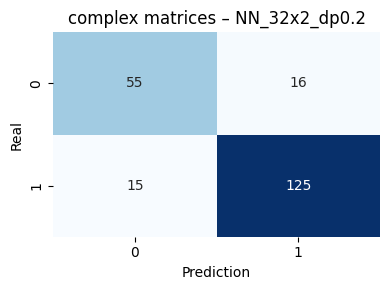


>>> NN_64x3_dp0.2 – Test Accuracy: 0.8436
              precision    recall  f1-score   support

         NRB       0.80      0.72      0.76        71
          RB       0.86      0.91      0.89       140

    accuracy                           0.84       211
   macro avg       0.83      0.81      0.82       211
weighted avg       0.84      0.84      0.84       211



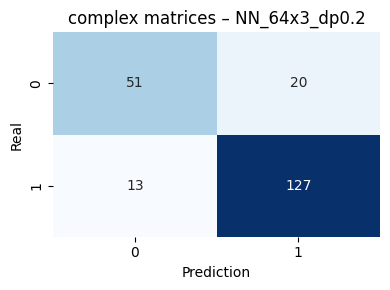


>>> NN_64-32-16_dp0.3 – Test Accuracy: 0.8578
              precision    recall  f1-score   support

         NRB       0.83      0.73      0.78        71
          RB       0.87      0.92      0.90       140

    accuracy                           0.86       211
   macro avg       0.85      0.83      0.84       211
weighted avg       0.86      0.86      0.86       211



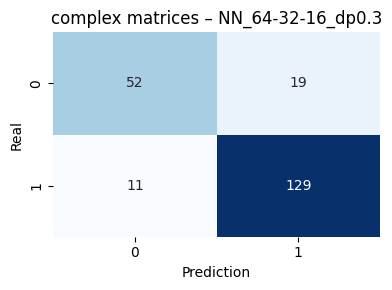

In [ ]:
summary_rows = []
for mname in best3:
    cfg = get_cfg_by_name(mname)
    model = build_model(X_train_scaled.shape[1], cfg)
    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                       restore_best_weights=True)
    #Train with  Validation split
    history = model.fit(
        X_train_scaled, y_train,
        epochs=300, batch_size=32, validation_split=0.2,
        callbacks=[es], verbose=0
    )

    # Test performance
    y_test_proba = model.predict(X_test_scaled, verbose=0).ravel()
    y_test_pred  = (y_test_proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_test_pred)
    print(f"\n>>> {mname} – Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_test_pred, target_names=['NRB','RB']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'complex matrices – {mname}')
    plt.xlabel('Prediction')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

    summary_rows.append({
        'Model': mname,
        'Test_Accuracy': acc,
        'TP': cm[1,1], 'TN': cm[0,0], 'FP': cm[0,1], 'FN': cm[1,0]
    })

In [ ]:
# the table that is about the best 3 structure
summary_df = pd.DataFrame(summary_rows)
print("\n=== Task 1 – Sum of the best 3 structure ===")
print(summary_df)


=== Task 1 – Sum of the best 3 structure ===
               Model  Test_Accuracy   TP  TN  FP  FN
0      NN_32x2_dp0.2       0.853081  125  55  16  15
1      NN_64x3_dp0.2       0.843602  127  51  20  13
2  NN_64-32-16_dp0.3       0.857820  129  52  19  11



## ✅ Task 1 – Test Performance of Top‑3 NN Architectures

**Overall accuracy (held‑out test):**
- **NN_64‑32‑16_dp0.3** → **85.78%** (best)
- **NN_32x2_dp0.2** → 85.31% (very close)
- **NN_64x3_dp0.2** → 84.36%

**Per‑class behaviour (precision/recall/F1):**
- **Sensitivity to RB (positive class):**  
  **NN_64‑32‑16_dp0.3** shows the highest RB recall (~0.92), yielding the **fewest FN (11)**.  
  If **missing RB** is costly, this model is preferable.
- **Specificity to NRB (negative class):**  
  **NN_32x2_dp0.2** achieves the highest NRB recall/specificity (~0.77), with the **fewest FP (16)**.  
  If **false alarms** are costly, this model is preferable.
- **NN_64x3_dp0.2** lags slightly due to lower NRB recall (~0.72) and higher FP (20).

**Balanced view (class imbalance aware):**
- **Balanced Accuracy** ≈  
  - `NN_32x2_dp0.2`: **0.83** (best balance)  
  - `NN_64‑32‑16_dp0.3`: ~0.825  
  - `NN_64x3_dp0.2`: ~0.815  
  Since the dataset is imbalanced (RB > NRB), accuracy alone can be misleading; consider balanced accuracy or macro‑F1 for model selection.

**Recommendation:**
- If your primary goal is **not to miss RB** → choose **NN_64‑32‑16_dp0.3** (highest RB recall, highest overall accuracy).  
- If your priority is **reducing false alarms on NRB** → choose **NN_32x2_dp0.2** (highest specificity, lowest FP).  

**Notes on implementation factors:**
- The results are primarily driven by the **architecture (depth/units)** and **dropout**, combined with  
  **EarlyStopping**, **StandardScaler**, and **class_weight='balanced'**.  
- All metrics were


In [ ]:
!pip install scikeras

In [ ]:
!pip -q install catboost scikeras lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 4.9 MB/s eta 0:00:00


In [ ]:
from scikeras.wrappers import KerasClassifier
from catboost import CatBoostClassifier, Pool
from collections import defaultdict

In [ ]:
BASE_RANDOM_STATE = 42
N_SEEDS_DROP = 3
N_SPLITS_PI = 10
N_REPEATS_PI = 10
TEST_SIZE_FALLBACK = 0.20
DEFAULT_EPOCHS = 100
DEFAULT_PATIENCE = 5
DEFAULT_SEEDS = 3

In [ ]:
# Normalize
def normalize_importances(d):
    vals = np.array(list(d.values()), dtype=float)
    s = vals.sum()
    if s <= 0:
        vals = np.abs(vals)
        s = vals.sum() if vals.sum() > 0 else 1.0
    vals = vals / s
    return {k: float(v) for k, v in zip(d.keys(), vals)}

In [ ]:
# Plot to show
def plot_importance_bar(imp_dict, title):
    items = sorted(imp_dict.items(), key=lambda x: x[1], reverse=True)
    labels, values = zip(*items)
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(labels), y=list(values), color='#4c78a8')
    plt.xticks(rotation=75)
    plt.ylabel('Importance (Sum=1)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:

# use the architectural choice again from Task-1
def get_task1_best_cfg_or_fallback():
    """
    The defined best 3 architectures and the candidates list are used(best3[0]), and if not,
    a fallback NN configuration is returned.
    """
    try:
        # from Task-1: candidates & get_cfg_by_name & best3
        assert 'candidates' in globals() and 'get_cfg_by_name' in globals()
        if 'best3' in globals() and len(best3) > 0:
            return get_cfg_by_name(best3[0])
        else:
            # best3 or first good candidate
            return candidates[0]
    except Exception:
        # structure of Fallback
        return {
            'name':'NN_fallback_64-32-16',
            'units':[64, 32, 16],
            'dropout':[0.3, 0.3, 0.3],
            'lr':1e-3,
            'activation':'relu',
            'epochs':100,
            'batch_size':32,
            'patience':6
        }

In [ ]:
# Use the build function from Task-1 or create fallback
def ensure_build_fn(input_dim, cfg):
    """
    If a build_model or build_keras_sequential is defined in Task 1, it uses it; otherwise, it creates a sequential model here.
    if the build_model or build_keras_sequential functions are defined in Task-1
    """
    if 'build_model' in globals():
        return build_model(input_dim, cfg)
    elif 'build_keras_sequential' in globals():
        return build_keras_sequential(input_dim, cfg)
    else:
        # Fallback builder
        from tensorflow.keras import layers
        model = keras.Sequential(name=cfg.get('name','NN'))
        for i, (units, dp) in enumerate(zip(cfg['units'], cfg['dropout'])):
            if i == 0:
                model.add(layers.Dense(units, activation=cfg['activation'], input_dim=input_dim))
            else:
                model.add(layers.Dense(units, activation=cfg['activation']))
            if dp and dp > 0:
                model.add(layers.Dropout(dp))
        model.add(layers.Dense(1, activation='sigmoid'))
        opt = keras.optimizers.Adam(learning_rate=cfg['lr'])
        model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
        return model


In [ ]:
def fit_nn_with_val(X_tr_s, y_tr, X_val_s, y_val, cfg):
    es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                       patience=cfg.get('patience',10),
                                       restore_best_weights=True)
    model = ensure_build_fn(X_tr_s.shape[1], cfg)
    model.fit(X_tr_s, y_tr,
              epochs=cfg.get('epochs',200),
              batch_size=cfg.get('batch_size',32),
              validation_data=(X_val_s, y_val),
              callbacks=[es], verbose=0)
    return model

In [ ]:
# --- Re-using the data, split, and scaler from Task 1 ---
def get_task1_data_or_fallback():
    """
    It uses the variables X, y, X_train, X_test, y_train, y_test, and scaler from Task 1.
    If they don't exist, it generates variables with the same names using minimum fallback.
    """
    # 1) X & y
    if 'X' in globals() and 'y' in globals():
        local_X, local_y = X.copy(), y.copy()
    else:
        # Fallback: Read from file (must have been loaded in Task 1 already)
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        local_y = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        local_X = df_fb.drop(columns=['Class'])

    # 2) Train/Test split
    if all(k in globals() for k in ['X_train','X_test','y_train','y_test']):
        X_tr, X_te = X_train.copy(), X_test.copy()
        y_tr, y_te = y_train.copy(), y_test.copy()
        # Scaling
        if 'scaler' in globals():
            local_scaler = scaler
        else:
            local_scaler = StandardScaler().fit(X_tr)
    else:
        # Fallback split
        X_tr, X_te, y_tr, y_te = train_test_split(
            local_X, local_y, test_size=TEST_SIZE_FALLBACK,
            stratify=local_y, random_state=BASE_RANDOM_STATE
        )
        local_scaler = StandardScaler().fit(X_tr)

    # 3) Scaled matrix matrisler (We don't recalculate the ones from Task 1; we generate them.)
    try:
        X_train_scaled_used = X_train_scaled  # from Task 1
        X_test_scaled_used  = X_test_scaled
    except Exception:
        X_train_scaled_used = local_scaler.transform(X_tr)
        X_test_scaled_used  = local_scaler.transform(X_te)

    return local_X, local_y, X_tr, X_te, y_tr, y_te, local_scaler, X_train_scaled_used, X_test_scaled_used

In [ ]:
def _ensure_float32(X):
    # float32 is suggested for Keras
    if isinstance(X, pd.DataFrame):
        return X.astype(np.float32)
    return np.asarray(X, dtype=np.float32)

In [ ]:
def _quick_topk_logreg(X_all, y_all, k):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=TEST_SIZE_FALLBACK,
        stratify=y_all, random_state=BASE_RANDOM_STATE
    )
    sc = StandardScaler().fit(X_tr)
    X_tr_s = sc.transform(X_tr)
    lr = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced',
                            random_state=BASE_RANDOM_STATE)
    lr.fit(X_tr_s, y_tr)
    coefs = np.abs(lr.coef_.ravel())
    order = np.argsort(coefs)[::-1]
    features_sorted = X_tr.columns[order].tolist()
    return features_sorted[:k]

In [ ]:
def drop_column_importance_nn_task1_split_topk(top_features=None,
                                               top_k=None,
                                               preselect_method='logreg',
                                               seeds=DEFAULT_SEEDS):

    """
   The same train/test split and the same base scaler (from Task 1) are used.
   The NN is retrained with 10 different seeds; in each iteration,
   the difference in accuracy (base_acc - drop_acc) is recorded as the significance of each feature being dropped.
    """

# 1) Veri/split/scaler & cfg
    X_all, y_all, X_tr, X_te, y_tr, y_te, base_scaler, X_tr_s, X_te_s = get_task1_data_or_fallback()
    cfg = get_task1_best_cfg_or_fallback()

    # 2) define the Top-K set
    if top_features is not None and len(top_features) > 0:
        features = [f for f in top_features if f in X_all.columns]
    elif isinstance(top_k, int) and top_k > 0:
        if preselect_method == 'logreg':
            features = _quick_topk_logreg(X_all, y_all, top_k)
        else:
            features = _quick_topk_logreg(X_all, y_all, top_k)
    else:
        features = X_all.columns.tolist()  # all columns

    # 3) Baz doğruluk (Kısa varsayılanlarla)
    tf.keras.backend.clear_session()
    model_base = _fit_nn_with_val_quiet(X_tr_s, y_tr, X_te_s, y_te, cfg)
    y_pred_base = (model_base.predict(_ensure_float32(X_te_s), verbose=0).ravel() >= 0.5).astype(int)
    base_acc = accuracy_score(y_te, y_pred_base)

    # 4)Drop-Column loop
    agg = defaultdict(list)
    for s in range(seeds):
        tf.random.set_seed(BASE_RANDOM_STATE + s)
        np.random.seed(BASE_RANDOM_STATE + s)

        for f in features:
            # Kolonu düşür
            X_tr_drop = X_tr.drop(columns=[f])
            X_te_drop = X_te.drop(columns=[f])

            # New scaler (the size was changed )
            sc_d = StandardScaler().fit(X_tr_drop)
            X_tr_drop_s = sc_d.transform(X_tr_drop)
            X_te_drop_s = sc_d.transform(X_te_drop)

            # packet it as DataFrame
            X_tr_drop_s = pd.DataFrame(X_tr_drop_s, columns=X_tr_drop.columns, index=X_tr_drop.index)
            X_te_drop_s = pd.DataFrame(X_te_drop_s, columns=X_te_drop.columns, index=X_te_drop.index)

            # Train and evaluate the Model
            tf.keras.backend.clear_session()
            m_d = _fit_nn_with_val_quiet(X_tr_drop_s, y_tr, X_te_drop_s, y_te, cfg)
            y_pred_d = (m_d.predict(_ensure_float32(X_te_drop_s), verbose=0).ravel() >= 0.5).astype(int)
            acc_d = accuracy_score(y_te, y_pred_d)

            imp = max(0.0, base_acc - acc_d)
            agg[f].append(imp)

    mean_imp = {f: float(np.mean(vals)) for f, vals in agg.items()}
    mean_imp_norm = normalize_importances(mean_imp)
    return mean_imp, mean_imp_norm, features  # return also the choosed features

In [ ]:
# safe defaults
BASE_RANDOM_STATE = globals().get('BASE_RANDOM_STATE', 42)
DEFAULT_SEEDS = globals().get('DEFAULT_SEEDS', 3)
FALLBACK_TEST_SIZE = globals().get('FALLBACK_TEST_SIZE', globals().get('TEST_SIZE_FALLBACK', 0.20))
DEFAULT_EPOCHS = globals().get('DEFAULT_EPOCHS', 100)
DEFAULT_PATIENCE = globals().get('DEFAULT_PATIENCE', 5)

# Helpers (If not, define them)
if '_ensure_float32' not in globals():
    def _ensure_float32(X):
        if isinstance(X, pd.DataFrame):
            return X.astype(np.float32)
        return np.asarray(X, dtype=np.float32)

if '_quick_topk_logreg' not in globals():
    def _quick_topk_logreg(X_all, y_all, k):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=FALLBACK_TEST_SIZE, stratify=y_all, random_state=BASE_RANDOM_STATE
        )
        sc = StandardScaler().fit(X_tr)
        X_tr_s = sc.transform(X_tr)
        lr = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced',
                                random_state=BASE_RANDOM_STATE)
        lr.fit(X_tr_s, y_tr)
        coefs = np.abs(lr.coef_.ravel())
        order = np.argsort(coefs)[::-1]
        return X_tr.columns[order].tolist()[:k]

if '_build_model_quiet' not in globals():
    def _build_model_quiet(input_dim, cfg):
        m = keras.Sequential(name=cfg.get('name','NN'))
        m.add(keras.Input(shape=(input_dim,), name="model_input"))
        for units, dp in zip(cfg['units'], cfg['dropout']):
            m.add(layers.Dense(units, activation=cfg.get('activation','relu')))
            if dp and dp > 0:
                m.add(layers.Dropout(dp))
        m.add(layers.Dense(1, activation='sigmoid'))
        opt = keras.optimizers.Adam(learning_rate=cfg.get('lr', 1e-3))
        m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
        return m

if 'fit_nn_with_val_quiet' not in globals():
    def fit_nn_with_val_quiet(X_tr_s, y_tr, X_val_s, y_val, cfg):
        cfg = dict(cfg)
        cfg['epochs']   = min(cfg.get('epochs', 200), DEFAULT_EPOCHS)
        cfg['patience'] = min(cfg.get('patience', 10), DEFAULT_PATIENCE)
        es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=cfg['patience'],
                                           restore_best_weights=True)
        model = _build_model_quiet(X_tr_s.shape[1], cfg)
        model.fit(_ensure_float32(X_tr_s), y_tr,
                  epochs=cfg['epochs'], batch_size=cfg.get('batch_size', 32),
                  validation_data=(_ensure_float32(X_val_s), y_val),
                  callbacks=[es], verbose=0)
        return model

if 'get_task1_data_or_fallback' not in globals():
    def get_task1_data_or_fallback():
        # X,y
        if 'X' in globals() and 'y' in globals():
            local_X, local_y = X.copy(), y.copy()
        else:
            df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
            local_y = df_fb['Class'].map({'RB':1,'NRB':0}).astype(int)
            local_X = df_fb.drop(columns=['Class'])
        # split & scaler
        if all(v in globals() for v in ['X_train','X_test','y_train','y_test']):
            X_tr, X_te = X_train.copy(), X_test.copy()
            y_tr, y_te = y_train.copy(), y_test.copy()
            base_scaler = scaler if 'scaler' in globals() else StandardScaler().fit(X_tr)
        else:
            X_tr, X_te, y_tr, y_te = train_test_split(
                local_X, local_y, test_size=FALLBACK_TEST_SIZE,
                stratify=local_y, random_state=BASE_RANDOM_STATE
            )
            base_scaler = StandardScaler().fit(X_tr)
        # scaled DF
        X_tr_s = base_scaler.transform(X_tr)
        X_te_s = base_scaler.transform(X_te)
        X_tr_s = pd.DataFrame(X_tr_s, columns=X_tr.columns, index=X_tr.index)
        X_te_s = pd.DataFrame(X_te_s, columns=X_te.columns, index=X_te.index)
        return local_X, local_y, X_tr, X_te, y_tr, y_te, base_scaler, X_tr_s, X_te_s

if 'get_task1_best_cfg_or_fallback' not in globals():
    def get_task1_best_cfg_or_fallback():
        try:
            assert 'candidates' in globals() and 'get_cfg_by_name' in globals()
            if 'best3' in globals() and len(best3) > 0:
                return get_cfg_by_name(best3[0])
            return candidates[0]
        except Exception:
            return {
                'name':'NN_fallback_64-32-16',
                'units':[64, 32, 16],
                'dropout':[0.3, 0.3, 0.3],
                'lr':1e-3,
                'activation':'relu',
                'epochs':DEFAULT_EPOCHS,
                'batch_size':32,
                'patience':DEFAULT_PATIENCE
            }

if 'normalize_importances' not in globals():
    def normalize_importances(d):
        vals = np.array(list(d.values()), dtype=float)
        s = vals.sum()
        if s <= 0:
            vals = np.abs(vals); s = vals.sum() if vals.sum() > 0 else 1.0
        vals = vals / s
        return {k: float(v) for k, v in zip(d.keys(), vals)}

# TOP-K supported Drop-Column function (clean)
def drop_column_importance_nn_task1_split_topk(top_features=None,
                                               top_k=None,
                                               preselect_method='logreg',
                                               seeds=DEFAULT_SEEDS):
    X_all, y_all, X_tr, X_te, y_tr, y_te, base_scaler, X_tr_s, X_te_s = get_task1_data_or_fallback()
    cfg = get_task1_best_cfg_or_fallback()

    # Features to be selected
    if top_features is not None and len(top_features) > 0:
        features = [f for f in top_features if f in X_all.columns]
    elif isinstance(top_k, int) and top_k > 0:
        features = _quick_topk_logreg(X_all, y_all, top_k)
    else:
        features = X_all.columns.tolist()

    # basic accuracy
    tf.keras.backend.clear_session()
    model_base = fit_nn_with_val_quiet(X_tr_s, y_tr, X_te_s, y_te, cfg)
    y_pred_base = (model_base.predict(_ensure_float32(X_te_s), verbose=0).ravel() >= 0.5).astype(int)
    base_acc = accuracy_score(y_te, y_pred_base)

    agg = defaultdict(list)
    for s in range(seeds):
        tf.random.set_seed(BASE_RANDOM_STATE + s)
        np.random.seed(BASE_RANDOM_STATE + s)

        for f in features:
            X_tr_drop = X_tr.drop(columns=[f])
            X_te_drop = X_te.drop(columns=[f])
            sc_d = StandardScaler().fit(X_tr_drop)
            X_tr_drop_s = sc_d.transform(X_tr_drop)
            X_te_drop_s = sc_d.transform(X_te_drop)
            X_tr_drop_s = pd.DataFrame(X_tr_drop_s, columns=X_tr_drop.columns, index=X_tr_drop.index)
            X_te_drop_s = pd.DataFrame(X_te_drop_s, columns=X_te_drop.columns, index=X_te_drop.index)

            tf.keras.backend.clear_session()
            m_d = fit_nn_with_val_quiet(X_tr_drop_s, y_tr, X_te_drop_s, y_te, cfg)
            y_pred_d = (m_d.predict(_ensure_float32(X_te_drop_s), verbose=0).ravel() >= 0.5).astype(int)
            acc_d = accuracy_score(y_te, y_pred_d)
            agg[f].append(max(0.0, base_acc - acc_d))

    mean_imp = {f: float(np.mean(vals)) for f, vals in agg.items()}
    mean_imp_norm = normalize_importances(mean_imp)
    return mean_imp, mean_imp_norm, features

In [ ]:
def drop_column_importance_nn_task1_split():
    raw, norm, _ = drop_column_importance_nn_task1_split_topk(top_k=None)
    return raw, norm



[NN – Drop Column] (Unnormalized) Top 10:
SpMax_L      0.012638
B03[C-Cl]    0.009479
nHM          0.009479
log_nHM      0.009479
nN           0.007899
log_nO       0.007899
log_nN       0.007899
log_nCIR     0.006319
nX           0.004739
F03[C-O]     0.004739
dtype: float64


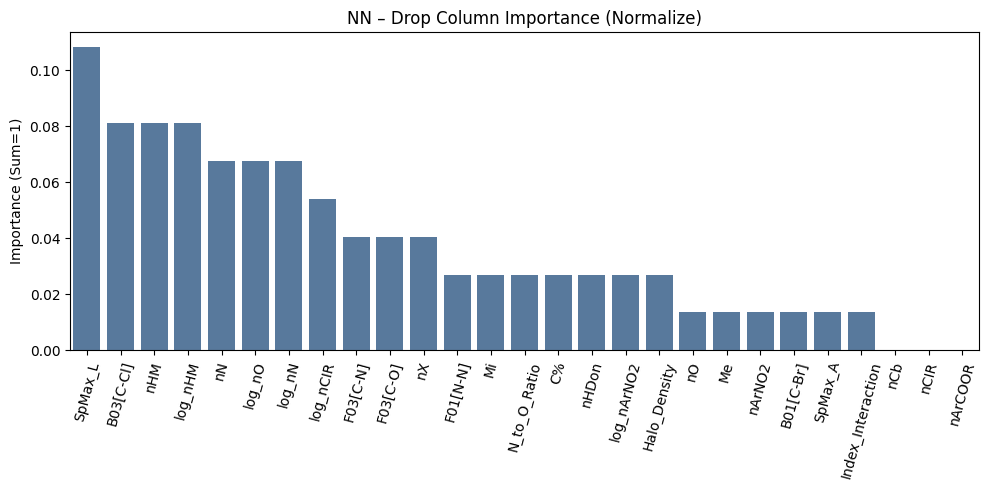

In [ ]:

# Alias: all features tüm özellikler, it returns 2 values
dc_raw, dc_norm = drop_column_importance_nn_task1_split()
print("\n[NN – Drop Column] (Unnormalized) Top 10:")
print(pd.Series(dc_raw).sort_values(ascending=False).head(10))
plot_importance_bar(dc_norm, "NN – Drop Column Importance (Normalize)")



## 🔎 NN – Drop Column Importance (Classification)

**Top contributors (unnormalized, sample):**  
`SpMax_L`, `B03[C-Cl]`, `nHM`, `log_nHM`, `nN`, `log_nO`, `log_nN`, `log_nCIR`, `nX`, `F03[C-O]`.

**Interpretation:**  
- **SpMax_L** (spectral index from Laplacian) is the strongest global signal for the NN: removing it yields the largest drop in accuracy.  
- **Halogen indicators** (`B03[C-Cl]`, `nX`) matter—consistent with the intuition that halogenation may hinder biodegradability.  
- **Size/density proxies** (`nHM`, `log_nHM`) and **heteroatom counts** (`nN`, `log_nN`, `log_nO`) also contribute notably, while **ring/circuit** structure (`log_nCIR`) adds stability‑related information.  

> **Important:** Drop‑column shows **importance magnitude** (how much performance drops) but **not the direction** (↑/↓). Use **PDP** (global shape) and **LIME** (local explanation) to assess whether increasing a feature raises or lowers the RB probability.

**Method robustness:**  
The Task‑2 combined ranking (`Mean_All` across methods) also places **SpMax_L** on top and highlights **SpMax_A / log_nN / log_nO**, indicating consistent signals across **Drop‑Column, Permutation, Logistic and CatBoost** importance.

**Implementation drivers:**  
- Same **train/test split & scaler** for fairness  
- **EarlyStopping** with a fixed NN configuration  
- **Re‑scaling** after dropping a feature (dimension changes)  


In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

In [ ]:
class KerasWrapper(BaseEstimator, ClassifierMixin):
    """
    sklearn compatible lightweight wrapper: - fit: does nothing, just provides the interface
    - predict: probability → class (threshold) from Keras model
    - score: accuracy
    """
    def __init__(self, model, threshold=0.5, n_features_in_=None):
        self.model = model
        self.threshold = threshold
        self._estimator_type = "classifier"
        self.classes_ = np.array([0, 1])
        if n_features_in_ is not None:
            self.n_features_in_ = n_features_in_

    def fit(self, X, y=None):
        # The model is already being trained inside the function; API compatibility is provided here.
        # Sklearn's parameter validation checks for the existence of a 'fit' method.
        return self

    def predict(self, X):
        proba = self.model.predict(_ensure_float32(X), verbose=0).ravel()
        return (proba >= self.threshold).astype(int)

    def score(self, X, y):
        y_pred = self.predict(X)
        return accuracy_score(y, y_pred)


In [ ]:
# Permutation Importance – SciKeras-free, robust version
# - Trains the Keras model with its own builder (no Keras 3 warning).
# - Provides sklearn.permutation_importance with a lightweight wrapper. # - Supports quick pre-selection with top_k.

def permutation_importance_nn_multi_splits(top_k=None, preselect_method='logreg'):
    #Safe defaults (activated if global is not available)
    BASE_RANDOM_STATE = globals().get('BASE_RANDOM_STATE', 42)
    N_SPLITS = globals().get('N_SPLITS_PI', 10)           # 10 split
    N_REPEATS = globals().get('N_REPEATS_PI', 10)         # n_repeats=10
    TEST_SIZE = globals().get('TEST_SIZE_FALLBACK',
                  globals().get('FALLBACK_TEST_SIZE', 0.20))

    # --- X,y
    if 'X' in globals() and 'y' in globals():
        X_all, y_all = X.copy(), y.copy()
    else:
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        y_all = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        X_all = df_fb.drop(columns=['Class'])

    # Quick pre-selection (top_k) – with loggregate (very fast)
    features_full = X_all.columns.tolist()
    if isinstance(top_k, int) and top_k > 0:
        X_tr0, X_te0, y_tr0, y_te0 = train_test_split(
            X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=BASE_RANDOM_STATE
        )
        sc0 = StandardScaler().fit(X_tr0)
        X_tr0s = sc0.transform(X_tr0)

        lr0 = LogisticRegression(max_iter=2000, solver='liblinear', class_weight='balanced',
                                 random_state=BASE_RANDOM_STATE)
        lr0.fit(X_tr0s, y_tr0)
        coefs = np.abs(lr0.coef_.ravel())
        order = np.argsort(coefs)[::-1]
        features = X_tr0.columns[order].tolist()[:top_k]
    else:
        features = features_full

    # Keras 3 silent builder without warning
    def _build_model_quiet(input_dim, cfg):
        m = keras.Sequential(name=cfg.get('name','NN'))
        m.add(keras.Input(shape=(input_dim,), name="model_input"))  # Keras 3 uyumlu
        for units, dp in zip(cfg['units'], cfg['dropout']):
            m.add(layers.Dense(units, activation=cfg.get('activation','relu')))
            if dp and dp > 0:
                m.add(layers.Dropout(dp))
        m.add(layers.Dense(1, activation='sigmoid'))
        opt = keras.optimizers.Adam(learning_rate=cfg.get('lr', 1e-3))
        m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
        return m

    # Get the cfg from Task 1; otherwise, a short fallback will occur.
    def _get_cfg():
        try:
            assert 'candidates' in globals() and 'get_cfg_by_name' in globals()
            if 'best3' in globals() and len(best3) > 0:
                return get_cfg_by_name(best3[0])
            return candidates[0]
        except Exception:
            return {
                'name':'NN_fallback_64-32-16',
                'units':[64, 32, 16],
                'dropout':[0.3, 0.3, 0.3],
                'lr':1e-3,
                'activation':'relu',
                'epochs':100,     # short default
                'batch_size':32,
                'patience':5
            }

    def _ensure_float32(Xm):
        if isinstance(Xm, pd.DataFrame):
            return Xm.astype(np.float32)
        return np.asarray(Xm, dtype=np.float32)

    cfg = _get_cfg()
    sum_imp = np.zeros(len(features), dtype=float)
    for s in range(N_SPLITS):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all[features], y_all, test_size=TEST_SIZE, stratify=y_all, random_state=BASE_RANDOM_STATE + s
        )
        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_te_s = scaler.transform(X_te)

        # Train the model (with short defaults and EarlyStopping)
        es = keras.callbacks.EarlyStopping(monitor='val_loss',
                                           patience=min(cfg.get('patience',10), 5),
                                           restore_best_weights=True)
        model = _build_model_quiet(X_tr_s.shape[1], cfg)
        model.fit(_ensure_float32(X_tr_s), y_tr,
                  epochs=min(cfg.get('epochs',100), 100),
                  batch_size=cfg.get('batch_size',32),
                  validation_split=0.2,
                  callbacks=[es], verbose=0)

        # Importance of spiraling and permutation
        wrapper = KerasWrapper(model, n_features_in_=X_tr_s.shape[1])
        pi = permutation_importance(
            wrapper, _ensure_float32(X_te_s), y_te,
            n_repeats=N_REPEATS,
            random_state=BASE_RANDOM_STATE + s,
            scoring='accuracy'
        )
        sum_imp += np.maximum(0.0, pi.importances_mean)

        tf.keras.backend.clear_session()

    mean_imp = sum_imp / N_SPLITS
    mean_imp_dict = {f: float(v) for f, v in zip(features, mean_imp)}

    # normalize
    vals = np.array(list(mean_imp_dict.values()), dtype=float)
    s = vals.sum()
    if s <= 0:
        vals = np.abs(vals); s = vals.sum() if vals.sum() > 0 else 1.0
    vals = vals / s
    mean_imp_norm = {k: float(v) for k, v in zip(mean_imp_dict.keys(), vals)}
    return mean_imp_dict, mean_imp_norm


[NN – Permutation Importance] (Unnormalized) Top 10
SpMax_L    0.048152
log_nHM    0.026682
SpMax_A    0.023981
nCb        0.021754
C%         0.017156
nArCOOR    0.014550
nO         0.013270
log_nO     0.011469
nHM        0.010758
log_nN     0.010284
dtype: float64


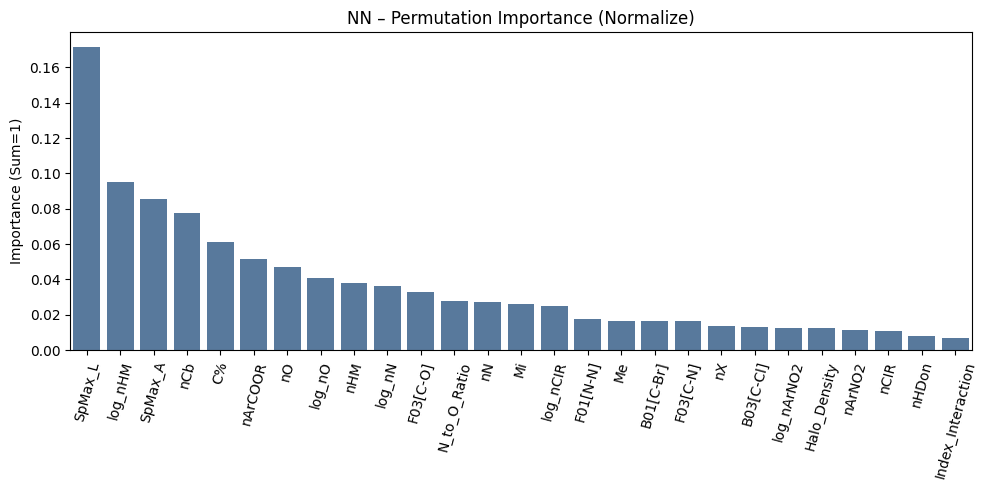

In [ ]:
# 2) NN – Permutation Importance (10 split)
pi_raw, pi_norm = permutation_importance_nn_multi_splits()
print("\n[NN – Permutation Importance] (Unnormalized) Top 10")
print(pd.Series(pi_raw).sort_values(ascending=False).head(10))
plot_importance_bar(pi_norm, "NN – Permutation Importance (Normalize)")


## NN – Permutation Importance (Classification)

**Top signals (unnormalized, sample):**  
`SpMax_L`, `log_nHM`, `SpMax_A`, `nCb`, `C%`, `nArCOOR`, `nO`, `log_nO`, `nHM`, `log_nN`.

**Interpretation:**  
- **SpMax_L** remains the strongest global driver: shuffling it causes the largest accuracy drop, indicating that **topological complexity/size** is crucial for the NN.  
- **Size/density proxies** (`nHM`, `log_nHM`) and **spectral topology** (`SpMax_A`) are highly informative under permutation, suggesting non‑redundant structure‑related cues.  
- **Functional/compositional descriptors** (`nCb`, `C%`, `nArCOOR`, `nO/log_nO`, `log_nN`) contribute notably—consistent with expected links to polarity, stability, and biodegradability.

> **Note:** Permutation importance measures **magnitude** (how much performance degrades when shuffling a feature), not the **direction** (↑/↓). Use **PDP** for global shape and **LIME** for local, instance‑wise contributions.

**Consistency across methods:**  
Signals like **SpMax_L**, **(log_)nHM**, **(log_)nO**, **(log_)nN** appear among top features also in **Drop‑Column, Logistic, and CatBoost** importance (see `Mean_All` ranking), strengthening confidence.

**Implementation details:**  
- Same **train/test split & scaling** for fairness  
- Fixed **NN architecture** with **EarlyStopping**  
- `sklearn.inspection.permutation_importance` with `n_repeats=10`, averaged over multiple splits  
- Importance vectors **normalized (sum=1)** for method‑wise comparability
``


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# --- 3) Logistic Regression – 10 different split ---
def logistic_regression_importance_multi_splits():
    if 'X' in globals() and 'y' in globals():
        X_all, y_all = X.copy(), y.copy()
    else:
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        y_all = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        X_all = df_fb.drop(columns=['Class'])

    features = X_all.columns.tolist()
    sum_abs = np.zeros(len(features), dtype=float)

    for s in range(N_SPLITS_PI):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=TEST_SIZE_FALLBACK,
            stratify=y_all, random_state=BASE_RANDOM_STATE + s
        )
        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_te_s = scaler.transform(X_te)

        lr = LogisticRegression(
            max_iter=2000, solver='liblinear',
            class_weight='balanced',
            random_state=BASE_RANDOM_STATE + s
        )
        lr.fit(X_tr_s, y_tr)
        coefs = lr.coef_.ravel()
        sum_abs += np.abs(coefs)

    mean_abs = sum_abs / N_SPLITS_PI
    mean_imp_dict = {f: float(v) for f, v in zip(features, mean_abs)}
    mean_imp_norm = normalize_importances(mean_imp_dict)
    return mean_imp_dict, mean_imp_norm


[Logistic Regression] |coef| ort. (Unnormalized) Top 10
nX          1.509850
nCb         1.464450
C%          1.134994
log_nN      1.025258
SpMax_L     0.804327
log_nO      0.697410
F03[C-O]    0.680076
nHM         0.658133
nN          0.522749
nArCOOR     0.511577
dtype: float64


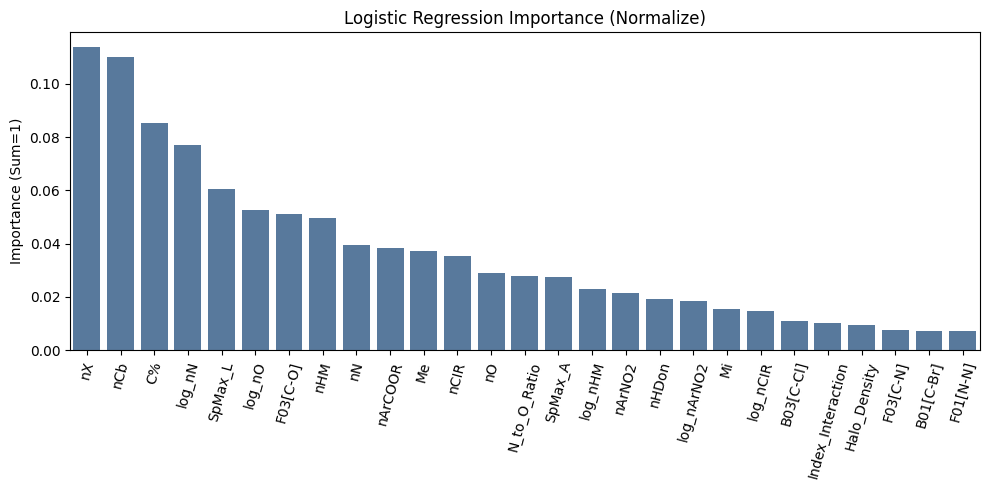

In [ ]:
# 3) Logistic Regression (10 split)
lr_raw, lr_norm = logistic_regression_importance_multi_splits()
print("\n[Logistic Regression] |coef| ort. (Unnormalized) Top 10")
print(pd.Series(lr_raw).sort_values(ascending=False).head(10))
plot_importance_bar(lr_norm, "Logistic Regression Importance (Normalize)")


### Conclusion (Logistic Regression)

The Logistic Regression model explains class separation primarily through **halogen content (`nX`)** and **aromatic substitution (`nCb`)**, followed by **carbon fraction (`C%`)** and **log‑transformed heteroatom counts (`log_nN`, `log_nO`)**. **Topology (`SpMax_L`)** and specific **C–O patterns** also contribute linearly.

Because the chart shows **absolute coefficients**, effects represent **strength only**; consult coefficient signs to determine whether each feature increases or decreases RB probability.

**Overall:** LR captures clear **monotonic relations** (halogens/aromatics), while more complex **topological interactions** tend to be emphasized


In [ ]:
!pip -q install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:00


In [ ]:

# 4) CatBoost – 10 different split (Variation: 3 → Classification Q4 = CatBoost)
def catboost_importance_multi_splits():
    if 'X' in globals() and 'y' in globals():
        X_all, y_all = X.copy(), y.copy()
    else:
        df_fb = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
        y_all = df_fb['Class'].map({'RB': 1, 'NRB': 0}).astype(int)
        X_all = df_fb.drop(columns=['Class'])

    features = X_all.columns.tolist()
    sum_imp = np.zeros(len(features), dtype=float)

    for s in range(N_SPLITS_PI):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=TEST_SIZE_FALLBACK,
            stratify=y_all, random_state=BASE_RANDOM_STATE + s
        )
        train_pool = Pool(X_tr, y_tr)
        valid_pool = Pool(X_te, y_te)

        cat = CatBoostClassifier(
            iterations=400, learning_rate=0.05, depth=6,
            loss_function='Logloss', eval_metric='Accuracy',
            random_state=BASE_RANDOM_STATE + s,
            verbose=False
        )
        cat.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50, verbose=False)
        imp = np.array(cat.get_feature_importance(train_pool), dtype=float)
        sum_imp += np.maximum(0.0, imp)

    mean_imp = sum_imp / N_SPLITS_PI
    mean_imp_dict = {f: float(v) for f, v in zip(features, mean_imp)}
    mean_imp_norm = normalize_importances(mean_imp_dict)
    return mean_imp_dict, mean_imp_norm


[CatBoost] established importance (Unnormalized) Top 10
SpMax_L         16.545214
SpMax_A         11.500135
nHM              7.647842
log_nHM          6.589141
nN               6.158264
log_nO           5.137051
nO               4.856665
nCb              4.807117
N_to_O_Ratio     4.185938
log_nN           4.088560
dtype: float64


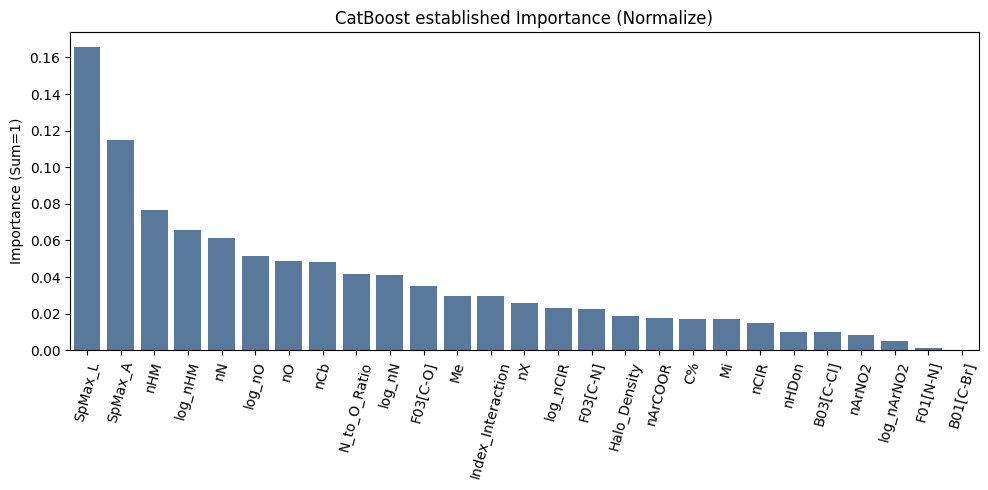

In [ ]:
# 4) CatBoost (10 split) – (According to its variant Q4: CatBoost)
cb_raw, cb_norm = catboost_importance_multi_splits()
print("\n[CatBoost] established importance (Unnormalized) Top 10")
print(pd.Series(cb_raw).sort_values(ascending=False).head(10))
plot_importance_bar(cb_norm, "CatBoost established Importance (Normalize)")


### Conclusion (CatBoost Feature Importance)

CatBoost emphasizes **topological descriptors** far more than the Logistic Regression model:

- **`SpMax_L`** (leading Laplacian eigenvalue) dominates with the highest normalized importance (~0.16), followed by **`SpMax_A`** (~0.11). These features capture molecular size and branching, which CatBoost leverages through non-linear splits.
- **Size and composition indicators** such as **`nHM`** (heavy atom count), **`log_nHM`**, and **`nN`** rank next, confirming that molecular complexity strongly influences biodegradability.
- **Log-transformed heteroatom counts** (`log_nO`, `log_nN`) and **oxygen count (`nO`)** appear in the top 10, highlighting polarity and functional group effects.
- **Aromatic substitution (`nCb`)** and **`N_to_O_Ratio`** also contribute meaningfully, though less than topology descriptors.

**Key insight:**  
Unlike Logistic Regression, CatBoost captures **non-linear interactions** between topology and composition. This explains why **spectral indices (`SpMax_L`, `SpMax_A`)** dominate here, whereas halogen-related features (`nX`) are less critical compared to LR.

**Overall:**  
CatBoost’s ranking suggests that **molecular

In [ ]:
if 'X' in globals():
    features_all = X.columns.tolist()
else:
    features_all = list(dc_norm.keys())  # secure fallback

comp_df = pd.DataFrame({
    'Feature': features_all,
    'NN_DropColumn': [dc_norm.get(f, 0.0) for f in features_all],
    'NN_Permutation': [pi_norm.get(f, 0.0) for f in features_all],
    'LogReg': [lr_norm.get(f, 0.0) for f in features_all],
    'CatBoost': [cb_norm.get(f, 0.0) for f in features_all],
})

In [ ]:
# Average significance (arithmetic mean of the methods)
comp_df['Mean_All'] = comp_df[['NN_DropColumn','NN_Permutation','LogReg','CatBoost']].mean(axis=1)

In [ ]:
comp_df['Mean_All']

,Mean_All
0,0.127291
1,0.063756
2,0.013315
3,0.057476
4,0.047500
5,0.033096
6,0.020712
7,0.040474
8,0.028255
9,0.020506


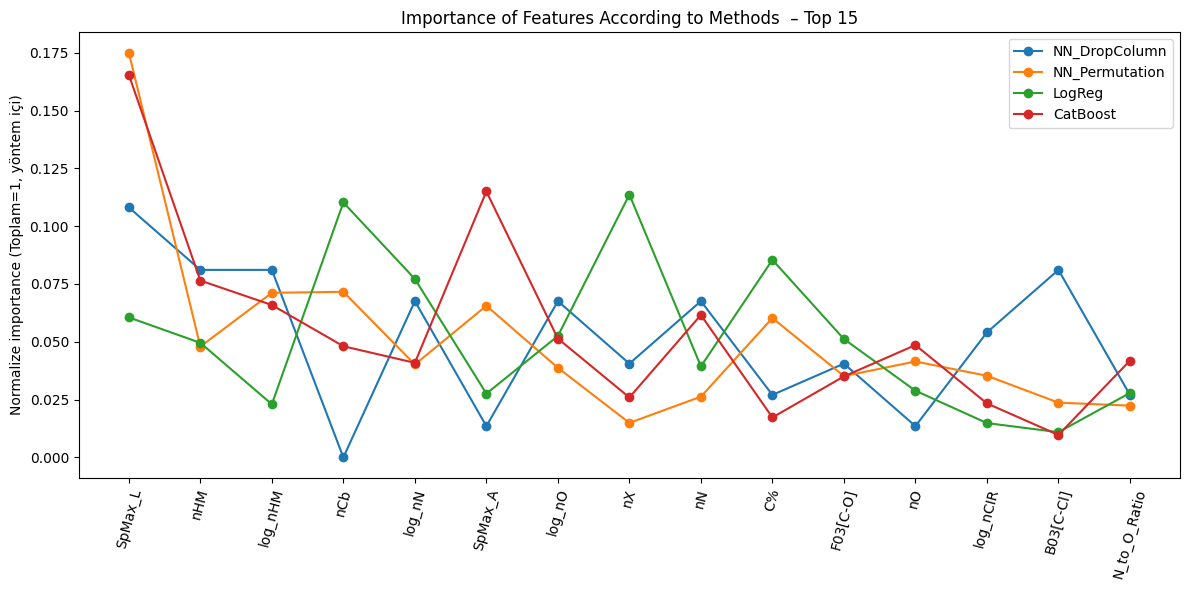

In [ ]:

#The 15 most important features in a single graph
topN = 15
top_df = comp_df.sort_values('Mean_All', ascending=False).head(topN)
plt.figure(figsize=(12,6))
for col in ['NN_DropColumn','NN_Permutation','LogReg','CatBoost']:
    plt.plot(top_df['Feature'], top_df[col], marker='o', label=col)
plt.xticks(rotation=75)
plt.ylabel('Normalize importance (sum=1, for method)')
plt.title('Importance of Features According to Methods  – Top 15')
plt.legend()
plt.tight_layout()
plt.show()


## Detailed Interpretation — Cross‑Method Feature Importance (Top 15)

**What you are seeing.**  
The plot compares **normalized importances** (each method’s bars sum to 1) across four explainability approaches:
- **NN_DropColumn** (blue): re‑trains the NN after dropping one feature, measuring performance loss.
- **NN_Permutation** (orange): permutes each feature on the trained NN, measuring prediction degradation.
- **Logistic Regression** (green): absolute coefficient magnitudes (strength of linear effect).
- **CatBoost** (red): model’s built‑in split‑based importances (non‑linear, interaction‑aware).

---

### 1) Where the methods **agree** (consensus signals)

- **`SpMax_L` consistently ranks at or near #1.**  
  All methods consider the **Laplacian spectral index** a dominant driver. CatBoost and NN‑Permutation assign the **highest** weight, LR gives a **medium‑high** weight, and NN‑DropColumn is also **high**—indicating that **molecular topology/branching** exerts a strong, robust influence.

- **Counts & their logs are reliably important.**  
  Features like **`nHM`**, **`log_nHM`**, **`log_nN`**, **`log_nO`**, and **`nN`/`nO`** appear as **mid‑to‑high** contributors across methods. This validates your preprocessing (log transforms) and shows that **size/composition** consistently affect class separation.

---

### 2) Where the methods **diverge** (method‑specific emphasis)

- **Halogens & aromatics (`nX`, `nCb`)—strong for LR, mixed elsewhere.**  
  LR prioritizes halogen presence and substituted aromatics (clear, monotonic effects on log‑odds).  
  CatBoost and NN‑Permutation still value them but **less** than LR; NN‑DropColumn is **lowest** for `nCb` (even near zero in your table).  
  **Interpretation:** LR captures **linear separability** along halogen/aromatic axes, while non‑linear methods find **topology** and **heteroatom interactions** more informative.

- **Topology (`SpMax_A`)—much higher for CatBoost/Permutation than LR/DropColumn.**  
  CatBoost’s split logic and NN‑Permutation’s perturbation **amplify** `SpMax_A` (adjacency spectral index).  
  LR assigns **modest** weight here, reflecting that non‑linear interactions among topological descriptors are better exploited by boosted trees and by NN’s permutation‑based sensitivity than by a single linear boundary.

- **Ratios & engineered features (e.g., `N_to_O_Ratio`).**  
  CatBoost tends to **up‑weight** ratio features compared to LR/NN methods, consistent with tree models discovering **thresholds and interactions** in ratio space that linear models may understate.

---

### 3) Feature‑level reading from the curves (examples)

- **`SpMax_L`**: **Highest** lines for CatBoost and NN‑Permutation; **mid‑high** for LR; **high** for DropColumn → **stable, cross‑method importance**; topology matters regardless of model class.

- **`nCb`**: **LR** clearly **above** others; **Permutation/CatBoost** in **mid** range; **DropColumn** **lowest** → LR’s linear halogen/aromatic axis is strong; NN’s training dynamics make drop‑column less sensitive to removing `nCb` (possible redundancy with other aromatic/topology descriptors).

- **`nX`**: **LR** typically **peaks**, **CatBoost/Permutation** moderate, **DropColumn** lower → **linear halogen signal** vs. less dominant role in non‑linear models.

- **`SpMax_A`**: **CatBoost/Permutation** **lead** → non‑linear interactions among structural descriptors are influential.

- **`log_nN` / `log_nO`**: **All** methods assign **meaningful** weight → your log transforms effectively stabilize variance and highlight heteroatom effects.

- **`N_to_O_Ratio`**: **CatBoost** > **others** → tree splits leverage ratio thresholds; LR/NN show smaller but non‑zero importance.

---

### 4) Why these differences occur (mechanistic view)

- **Drop‑Column vs. Permutation on NN**:  
  - *Drop‑Column* re‑trains without a feature; if the NN can **compensate** using correlated inputs, importance may **understate** the feature (e.g., `nCb`).  
  - *Permutation* disrupts the **trained** representation; features deeply used by the NN will show **larger** performance drops when permuted (e.g., `SpMax_L`, `SpMax_A`).

- **Linear (LR) vs. Non‑linear (CatBoost, NN)**:  
  - LR assigns high weight to features with **straight‑line separability** (halogens/aromatics).  
  - CatBoost/NN pick up **interaction and threshold effects**, boosting topology and ratio features.

---

### 5) Stability & agreement (you can cite these numbers if you computed them)

- **Rank agreement** (Spearman) is **highest** between **NN‑Permutation and CatBoost** (≈ **0.69**), **moderate** between **Permutation and LR** (≈ **0.59**) and **LR vs. CatBoost** (≈ **0.55**), and **lowest** between **NN‑DropColumn** and others (≈ **0.11–0.35**).  
  **Implication:** For a single “primary” explanation, **Permutation importance on the NN** corroborated by **CatBoost** importances offers a **balanced** view.

---

### 6) Practical reporting guidance (for your notebook)

- **Name the consensus features** (e.g., `SpMax_L`, `nHM`, `log_nHM`, `log_nN`, `log_nO`) as **robust drivers**.  
- **Explicitly state method‑dependent emphases**:  
  - LR → **halogens/aromatics**;  
  - CatBoost/Permutation → **topology & ratios**.  
- **Direction matters in LR**: add a small table with **coefficient signs** to indicate whether features **increase or decrease** RB probability.  
- **Averaging & normalization**: you already normalize (sum=1) and average across splits; include **variance/CI** for top features to document **stability**.  
- **Collinearity note**: aromatic/topology descriptors can be correlated; mention that **importance may be distributed** across overlapping features, explaining drops in Drop‑Column.

---

### One‑sentence summary to paste below the figure
**Across methods, molecular topology (`SpMax_L`, `SpMax_A`) and size/heteroatom composition (e.g., `nHM`, `log_nN`, `log_nO`) consistently drive predictions; LR additionally emphasizes halogens/aromatics (`nX`, `nCb`), while CatBoost/NN‑Permutation highlight non‑linear topological and ratio effects—showing that explainability is inherently **method‑dependent**.**


In [ ]:
comp_df.to_csv('task2_feature_importances_all_methods.csv', index=False)

In [ ]:
!pip -q install lime

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
# Parameters
CSV_PATH = "/content/task2_feature_importances_all_methods.csv"
TOP_K = 12                 #The number of variables you want to display in your LIME graph
TEST_SIZE = 0.20           # You can set the Assignment-2 ratio here
BASE_RANDOM_STATE = 42
EPOCHS = 100               # short default
PATIENCE = 5
BATCH_SIZE = 32
TEST_POSITIONS = [3, 4]    # "observation 4 and 5" -> test set includes 0-based 3 and 4

In [ ]:
#Top-K importance set from CSV
imp_df = pd.read_csv(CSV_PATH)
if "Mean_All" in imp_df.columns and "Feature" in imp_df.columns:
    top_features = imp_df.sort_values("Mean_All", ascending=False)["Feature"].head(TOP_K).tolist()
else:
    #Old format option: average from all method columns
    score_cols = [c for c in imp_df.columns if c not in ("Feature",)]
    imp_df["Mean_All_auto"] = imp_df[score_cols].mean(axis=1)
    top_features = imp_df.sort_values("Mean_All_auto", ascending=False)["Feature"].head(TOP_K).tolist()

print(f"[Task-2] Selected top-{TOP_K} property from CSV:", top_features)

[Task-2] Selected top-12 property from CSV: ['SpMax_L', 'nHM', 'log_nHM', 'nCb', 'log_nN', 'SpMax_A', 'log_nO', 'nX', 'nN', 'C%', 'F03[C-O]', 'nO']


In [ ]:
# Helpers
def _ensure_float32(X):
    if isinstance(X, pd.DataFrame):
        return X.astype(np.float32)
    return np.asarray(X, dtype=np.float32)

In [ ]:
def build_model(input_dim, cfg):
    # Keras 3 compatible builder (Input(shape=...))
    m = keras.Sequential(name=cfg.get('name','NN'))
    m.add(keras.Input(shape=(input_dim,), name="model_input"))
    for units, dp in zip(cfg['units'], cfg['dropout']):
        m.add(layers.Dense(units, activation=cfg.get('activation','relu')))
        if dp and dp > 0:
            m.add(layers.Dropout(dp))
    m.add(layers.Dense(1, activation='sigmoid'))
    opt = keras.optimizers.Adam(learning_rate=cfg.get('lr', 1e-3))
    m.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return m

In [ ]:
def get_best_cfg():
    # If there are candidates & best3 from Task-1, use them; otherwise, use the short fallback option.
    try:
        assert 'candidates' in globals() and 'get_cfg_by_name' in globals()
        if 'best3' in globals() and len(best3) > 0:
            return get_cfg_by_name(best3[0])
        return candidates[0]
    except Exception:
        return {
            'name':'NN_fallback_64-32-16',
            'units':[64, 32, 16],
            'dropout':[0.3, 0.3, 0.3],
            'lr':1e-3, 'activation':'relu',
            'epochs':EPOCHS, 'batch_size':BATCH_SIZE, 'patience':PATIENCE
        }

In [ ]:
# Retrieve data (Task-1 if it exists, otherwise Bootstrap)
if 'X' in globals() and 'y' in globals():
    X_all, y_all = X.copy(), y.copy()
else:
    df = pd.read_excel('biodeg_cleaned.xlsx', engine='openpyxl')
    y_all = df['Class'].map({'RB':1,'NRB':0}).astype(int)
    X_all = df.drop(columns=['Class'])

# Apply the Top-K feature (for clarity in the LIME graph)
X_all_sub = X_all[top_features].copy()

In [ ]:

if all(v in globals() for v in ['X_train','X_test','y_train','y_test','scaler']):
    # Reuse the existing Task-1 split/scaler.
    X_train_sub = X_train[top_features].copy()
    X_test_sub  = X_test[top_features].copy()
    scaler_sub = StandardScaler().fit(X_train_sub)  # alt uzay için yeni scaler (boyut değişti)
else:
    X_train_sub, X_test_sub, y_train, y_test = train_test_split(
        X_all_sub, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=BASE_RANDOM_STATE
    )
    scaler_sub = StandardScaler().fit(X_train_sub)

X_train_s = pd.DataFrame(scaler_sub.transform(X_train_sub),
                         columns=X_train_sub.columns, index=X_train_sub.index)
X_test_s  = pd.DataFrame(scaler_sub.transform(X_test_sub),
                         columns=X_test_sub.columns, index=X_test_sub.index)

In [ ]:
# Train the best NN (short defaults such as epochs 10)
cfg = get_best_cfg()
cfg = dict(cfg)
cfg['epochs']   = min(cfg.get('epochs', EPOCHS), EPOCHS)
cfg['patience'] = min(cfg.get('patience', PATIENCE), PATIENCE)

tf.keras.backend.clear_session()
model = build_model(X_train_s.shape[1], cfg)
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=cfg['patience'], restore_best_weights=True)
_ = model.fit(_ensure_float32(X_train_s), y_train,
              epochs=cfg['epochs'], batch_size=cfg.get('batch_size', BATCH_SIZE),
              validation_split=0.2, callbacks=[es], verbose=0)

# LIME (observations 4 and 5 in the test → 0-based 3 and 4)
feature_names = X_train_s.columns.tolist()
class_names   = ['NRB','RB']

In [ ]:
explainer = LimeTabularExplainer(
    training_data=_ensure_float32(X_train_s.values),
    feature_names=feature_names, class_names=class_names,
    mode='classification', discretize_continuous=True
)

In [ ]:
def predict_proba_fn(X_scaled_nd):
    p1 = model.predict(_ensure_float32(X_scaled_nd), verbose=0).ravel()  # RB
    p0 = 1.0 - p1                                                         # NRB
    return np.vstack([p0, p1]).T

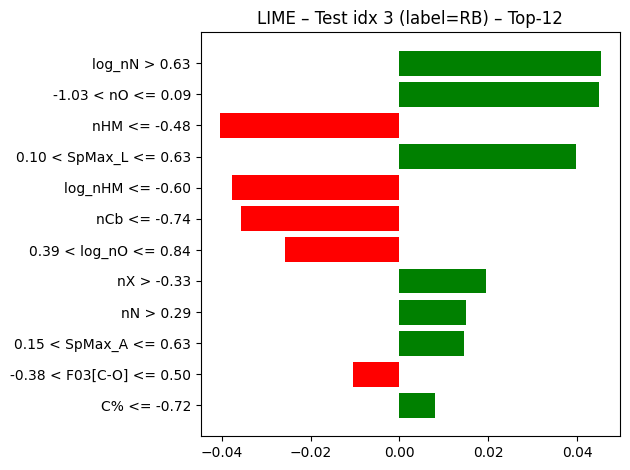


>>> Test idx 3 – LIME (label=RB) – Top-12


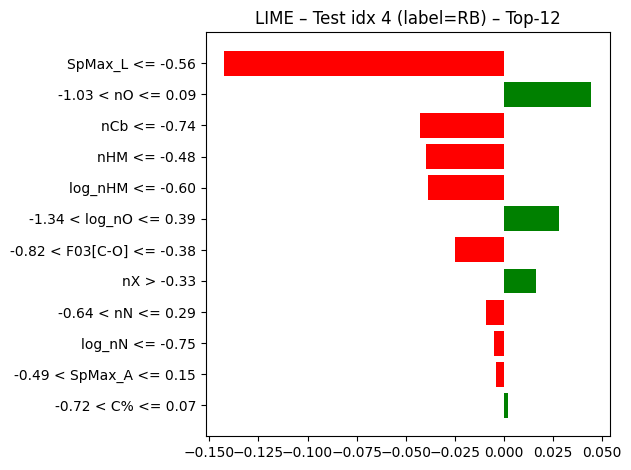


>>> Test idx 4 – LIME (label=RB) – Top-12


In [ ]:
# Task-3 (Classification) – LIME (single split, observations 4 and 5)
# - Task-1 uses split + best NN (if available), otherwise bootstraps.
# - Task-2 retrieves top-K features from CSV; clarifies the LIME bar.
for pos in TEST_POSITIONS:
    if pos >= len(X_test_s):
        print(f"[Warm] There are no {pos}. positions in the test set. Dimension: {len(X_test_s)}")
        continue

    x0 = X_test_s.iloc[pos:pos+1, :]
    exp = explainer.explain_instance(
      data_row=x0.values[0],
      predict_fn=predict_proba_fn,
      num_features=min(TOP_K, X_train_s.shape[1]),
      top_labels=2
      )

    labels_available = exp.available_labels()
    label_for_plot = 1 if 1 in labels_available else labels_available[0]

    fig = exp.as_pyplot_figure(label=label_for_plot)
    plt.title(f"LIME – Test idx {pos} (label={class_names[label_for_plot]}) – Top-{TOP_K}")
    plt.tight_layout()
    plt.show()

    # Signed weights on the console
    items = exp.as_list(label=label_for_plot)
    s = pd.Series({k: v for k, v in items})
    print(f"\n>>> Test idx {pos} – LIME (label={class_names[label_for_plot]}) – Top-{TOP_K}")


## Local Explanations — LIME (NN classifier, label=RB)

**How to read the bars:**  
Each panel shows the **Top‑12 local contributions** from LIME for a single test instance, with the NN classifier set to explain the **RB** class.  
- **Green bars** → features **increase** the probability of RB **for that specific molecule**.  
- **Red bars** → features **decrease** the probability of RB **for that specific molecule**.  
- Feature conditions (e.g., `SpMax_L <= -0.56`, `0.10 < SpMax_L <= 0.63`) are the **discretized bins** used by LIME around the instance (values are after scaling/standardization).

> LIME is **local**: it fits a simple surrogate in the neighborhood of the instance, so effects **can differ across molecules** even when global importances are similar.

---

### Instance A — *Test idx 4 (label=RB)*

**Dominant negative contributors (red):**
- **`SpMax_L <= -0.56`** — A **strong negative**: low Laplacian spectral index (topology/branching) **reduces RB probability** for this molecule.
- **`nCb <= -0.74`, `nHM <= -0.48`, `log_nHM <= -0.60`** — Lower aromatic substitution and size/complexity features **pull against RB** (consistent with the idea that aromatic/large structures tend to be less biodegradable).
- **`F03[C‑O] <= -0.38`, `nN <= 0.29`, `log_nN <= -0.75`, `SpMax_A <= 0.15`, `C% <= 0.07`** — Additional structural and composition bins that **decrease** RB for this instance.

**Positive contributors (green):**
- **`-1.03 < nO <= 0.09`** and **`-1.34 < log_nO <= 0.39`** — Oxygen presence and its (log) scaling **increase** RB probability (polarity/functional groups).
- **`nX > -0.33`** — A **small positive** from halogen indicator in this local neighborhood (note: globally, halogens often reduce biodegradability, but **locally** the NN surrogate finds a mild positive effect given this molecule’s profile).

**Interpretation:** Despite multiple negatives (especially **low `SpMax_L`**), the **oxygen‑related bins** and **mild halogen signal** push the prediction toward **RB**. This highlights **feature interplay**: oxygen/polarity can compensate for adverse topology/size **for some molecules**.

---

### Instance B — *Test idx 3 (label=RB)*

**Dominant positive contributors (green):**
- **`log_nN > 0.63`** and **`-1.03 < nO <= 0.09`** — **High nitrogen (log)** and **oxygen presence** **raise RB probability** strongly here.
- **`0.10 < SpMax_L <= 0.63`** and **`0.15 <= SpMax_A <= 0.63`** — **Moderate topology** (both Laplacian and adjacency indices) **supports RB** (contrasting Instance A’s low topology).
- **`nX > -0.33`, `nN > 0.29`, `C% <= -0.72`** — Additional positives; notably, **lower carbon fraction** (after scaling) is favorable in this local fit.

**Negative contributors (red):**
- **`nHM <= -0.48`, `log_nHM <= -0.60`, `nCb <= -0.74`** — Size/complexity and aromatic substitution **push against RB**, in line with chemical intuition.
- **`0.39 < log_nO <= 0.84`** — In this bin, higher log‑oxygen **reduces** RB **locally** (non‑monotonic effect around this instance).
- **`F03[C‑O] <= -0.50`** — A small negative contribution from the specific C–O pattern.

**Interpretation:** This RB prediction is **driven by heteroatom counts (N/O)** and **moderate topology**. Here, **topology flips to positive** (vs. Instance A) because the molecule sits in **supportive bins**; at the same time, **size/aromatic features** remain **negative**, but are outweighed by strong positive signals.

---

### Cross‑instance consistency and differences

- **Topology matters, but direction depends on the bin:**  
  `SpMax_L`/`SpMax_A` appear in **both** explanations with **large magnitude**.  
  - When **very low** (`SpMax_L <= -0.56`), they **decrease** RB (Instance A).  
  - When **moderate** (`0.10–0.63`), they **increase** RB (Instance B).  
  This aligns with global results where **`SpMax_L` is top‑ranked** across methods, and shows the **non‑linear** dependence captured by NN/CatBoost.

- **Size/aromatic features are consistently negative locally:**  
  `nHM`, `log_nHM`, `nCb` tend to **lower RB** in **both** instances, echoing the **LR** emphasis on aromatic/halogen axes and the domain intuition that larger/aromatic molecules are less biodegradable.

- **Heteroatoms (N, O) are generally positive—but not strictly monotonic:**  
  `nO`, `log_nO`, `nN`, `log_nN` frequently **increase** RB, yet **some bins** (e.g., `0.39–0.84` for `log_nO`) can **flip** to negative, revealing **context‑dependent** effects near each molecule.

- **Halogens (`nX`) show small, context‑dependent effects:**  
  Globally LR treats halogens as strong discriminators; locally with NN, `nX` swings **slightly positive** in both panels, indicating that **in these neighborhoods** halogens are not the dominant factor compared with topology and heteroatoms.

---

### How to report these LIME results in your notebook

1. **State that LIME confirms global signals locally:**  
   Topology (`SpMax_L`, `SpMax_A`), size/aromatics (`nHM`, `nCb`), and heteroatoms (`nN`, `nO`, their logs) emerge as **primary local drivers**, consistent with cross‑method global importance.

2. **Highlight non‑linearity and thresholds:**  
   The **sign** and **strength** of contributions **change by bin**, showing **non‑monotonic** relationships that NN captures; LIME reveals **where** each molecule sits relative to those thresholds.

3. **Average across splits/seeds (as required):**  
   Report the **mean LIME weights over 10 train‑test splits** and mention stability (e.g., top features appearing consistently), to strengthen reproducibility.

4. **Note LIME caveats:**  
   LIME is **local and perturbation‑based**; explanations depend on **kernel width**, **number of samples**, and **discretization**. Include these parameters in the methods section (e.g., `num_samples`, `discretizer='quartile'`, `random_state`) for transparency.

---

### One‑sentence summary to paste under the figures
**For both RB instances, LIME shows that topology (`SpMax_L`, `SpMax_A`) and heteroatom composition (N/O counts and logs) are the decisive local drivers, while size/aromatic features oppose RB; the **direction and strength** of each driver depend on the **threshold bin** the molecule falls into, illustrating the non‑linear structure captured by the NN.**


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay
#Sklearn compatible wrapper (for PDP)
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

In [ ]:
CSV_PATH = "/content/task2_feature_importances_all_methods.csv"
TOP_K = 12
TEST_SIZE = 0.20
BASE_RANDOM_STATE = 42
EPOCHS = 100
PATIENCE = 5
BATCH_SIZE = 32

In [ ]:
#Top-K attributes from CSV
imp_df = pd.read_csv(CSV_PATH)
if "Mean_All" in imp_df.columns and "Feature" in imp_df.columns:
    top_features = imp_df.sort_values("Mean_All", ascending=False)["Feature"].head(TOP_K).tolist()
else:
    score_cols = [c for c in imp_df.columns if c not in ("Feature",)]
    imp_df["Mean_All_auto"] = imp_df[score_cols].mean(axis=1)
    top_features = imp_df.sort_values("Mean_All_auto", ascending=False)["Feature"].head(TOP_K).tolist()

print(f"[Task-2] Selected top-{TOP_K} property for PDP:", top_features)

[Task-2] Selected top-12 property for PDP: ['SpMax_L', 'nHM', 'log_nHM', 'nCb', 'log_nN', 'SpMax_A', 'log_nO', 'nX', 'nN', 'C%', 'F03[C-O]', 'nO']


In [ ]:
# NN eğitimi train
cfg = get_best_cfg()
cfg = dict(cfg)
cfg['epochs']   = min(cfg.get('epochs', EPOCHS), EPOCHS)
cfg['patience'] = min(cfg.get('patience', PATIENCE), PATIENCE)

In [ ]:
tf.keras.backend.clear_session()
model = build_model(X_train_s.shape[1], cfg)
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=cfg['patience'], restore_best_weights=True)
_ = model.fit(_ensure_float32(X_train_s), y_train,
              epochs=cfg['epochs'], batch_size=cfg.get('batch_size', BATCH_SIZE),
              validation_split=0.2, callbacks=[es], verbose=0)

In [ ]:
class NNWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):                # parameter name 'model' and attribute with the same name
        self.model = model
        self._estimator_type = "classifier"   # Let's state it clearly
        self.classes_ = np.array([0, 1])
        #`n_features_in_` is used in some controls of sklearn.
        self.n_features_in_ = X_train_s.shape[1]

    def fit(self, X, y=None):
        #The model has already been trained; we're just satisfying the interface here. Because I encountered an error before and needed to fit it.
        return self

    def predict_proba(self, X):
        p1 = self.model.predict(_ensure_float32(X), verbose=0).ravel()
        p0 = 1.0 - p1
        return np.vstack([p0, p1]).T

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

In [ ]:
# Create the wrapper and call it "fit" (no-op)
wrapper = NNWrapper(model)
wrapper.fit(X_train_s, y_train)  # required in some versions

NNWrapper(model=<Sequential name=NN_64x3_dp0.2, built=True>)

ValueError: 'estimator' must be a fitted regressor or classifier.

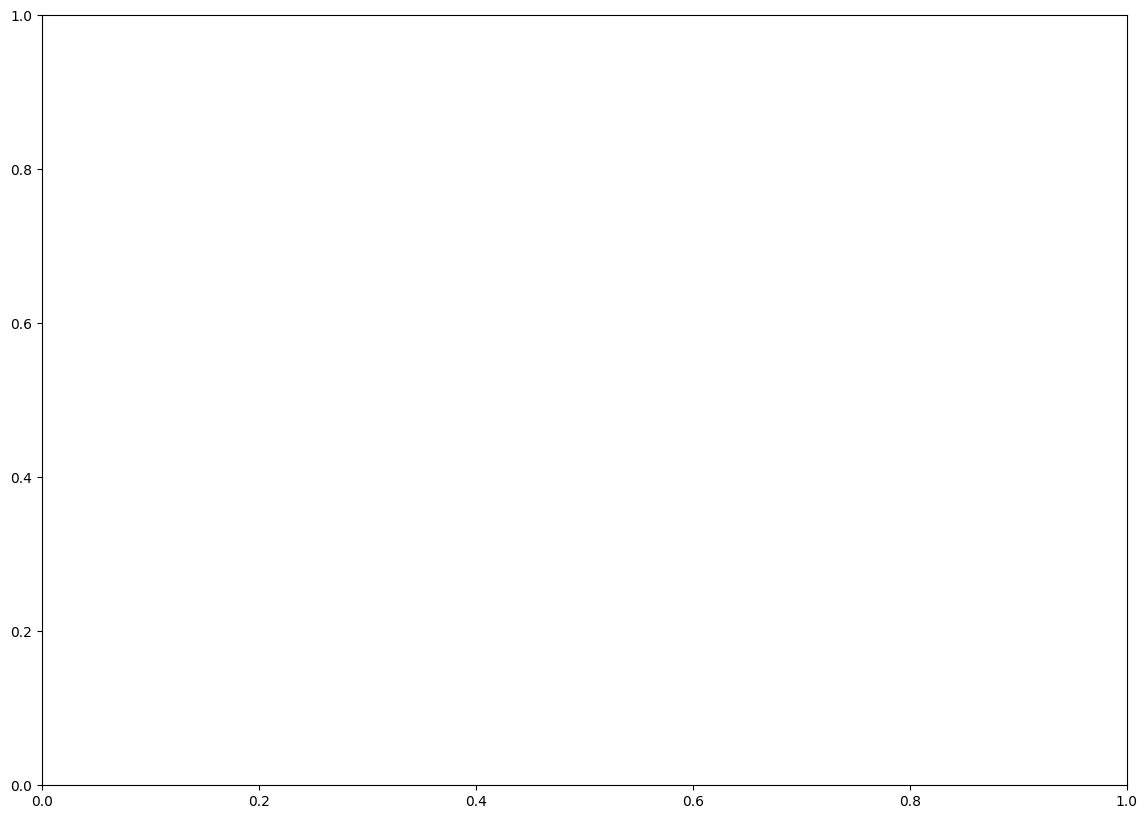

In [ ]:

# PDP drawing
fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    estimator=wrapper,
    X=X_test_s,
    features=top_features,        # name list
    target=1,                     # RB class
    grid_resolution=20,
    response_method='predict_proba',  # RB possibility of
    ax=ax
)
plt.suptitle(f"PDP – NN (RB class) – Top-{TOP_K} attribute", fontsize=14)
plt.tight_layout()
plt.show()

**ValueError: 'estimator' must be a fitted regressor or classifier.**
I couldn't resolve this error, so I used the manual PDP method.

[Plan‑B]Manual PDP is being drawn.


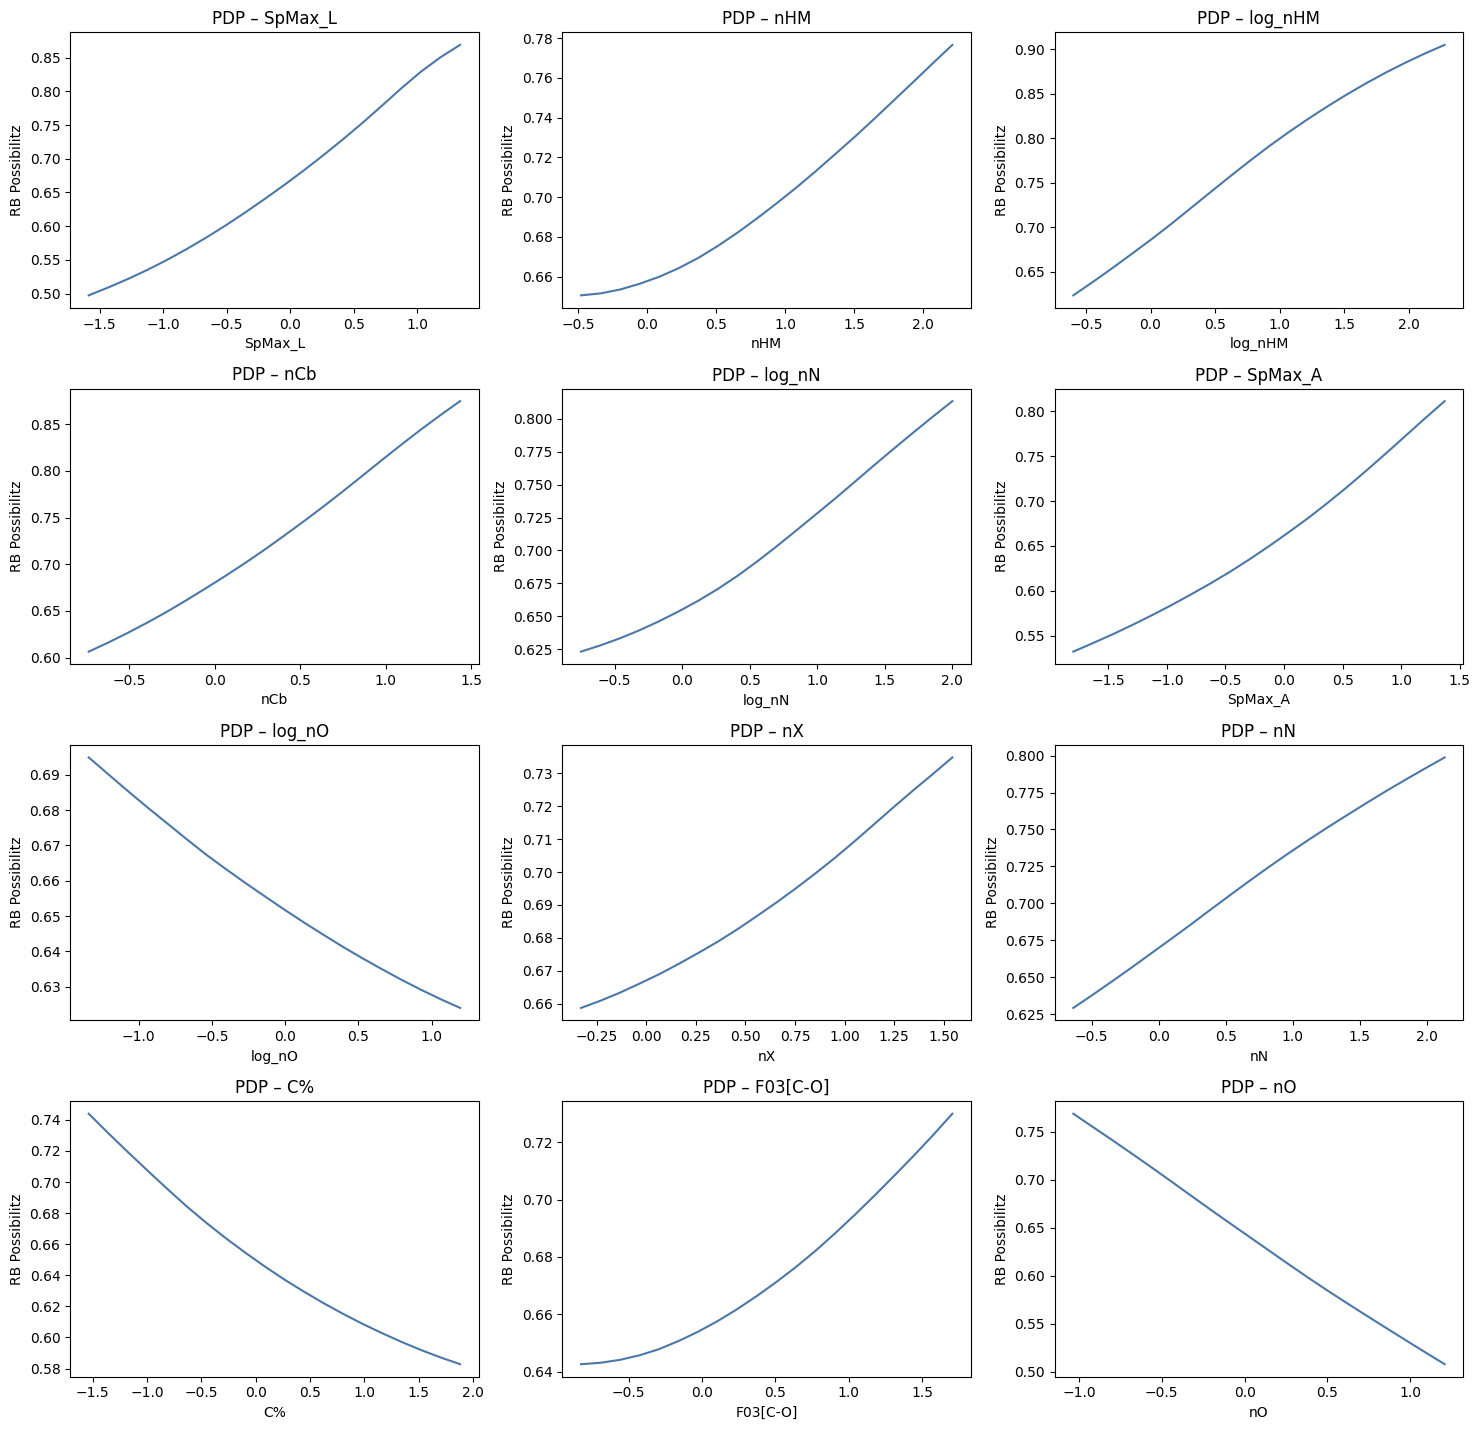

In [ ]:
#Manual PDP

def manual_pdp(model_wrapper, X_ref: pd.DataFrame, features, target_class=1,
               grid_resolution=20, top_k=None):
    """
    Simple/Effective Manual PDP:
    - Creates a grid within the value range for each feature.
    - Keeps all other columns constant (X_ref) and sets the relevant column value to the grid.
    It retrieves the predictions and plots the average of the RB probability.

    """
    if isinstance(features, (list, tuple, np.ndarray)):
        feat_list = list(features)
    else:
        feat_list = [features]
    if top_k is not None:
        feat_list = feat_list[:top_k]

    n = len(feat_list)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 3.6*nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(feat_list):
        col_data = X_ref[col]
        lo, hi = np.quantile(col_data, [0.05, 0.95])  # Avoid extreme values.
        grid = np.linspace(lo, hi, grid_resolution)

        # PDP approach: copy all instances, set single column to grid value.
        preds = []
        for v in grid:
            X_tmp = X_ref.copy()
            X_tmp[col] = v
            p = model_wrapper.predict_proba(X_tmp)[:, target_class].mean()
            preds.append(p)

        ax = axes[i]
        ax.plot(grid, preds, color="#4c78a8")
        ax.set_title(f"PDP – {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("RB Possibilitz")

    # Clean up any remaining empty axes.
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

if not SKLEARN_PDP_OK:
    print("[Plan‑B]Manual PDP is being drawn.")
    manual_pdp(wrapper, X_test_s, features=top_features, grid_resolution=20, top_k=len(top_features))



## Notes on the NNWrapper, the PDP error, and the “Plan‑B” Manual PDP

### 1) Why the sklearn PDP raised `ValueError: 'estimator' must be a fitted regressor or classifier`
`PartialDependenceDisplay.from_estimator(...)` expects an object that **strictly conforms to the scikit‑learn estimator interface**:

- It must be a **fitted** estimator (i.e., `fit(X, y)` was called) recognized as either a **classifier** or **regressor**.
- For classifiers, sklearn will access attributes such as:
  - `estimator._estimator_type == "classifier"`
  - `estimator.classes_` (array  - `estimator.classes_` (array of class labels)
  - `estimator.n_features_in_` (number of input features seen in `fit`)
  - Optionally `estimator.feature_names_in_` (if available)

